# Problem A: Recover Young's modulus in 1D Elastostatics
Consider a rod made of linearly elastic material subjected to some load. Static problems will be considered here, by which is meant it is not necessary to know how the load was applied, or how the material particles moved to reach the stressed state; it is necessary only that the load is applied slowly enough so that the accelerations are zero, or that it was applied sufficiently long ago that any vibrations have died away and movement has ceased. 

The equation governing the static response of the rod is: 
$$
-\frac{d}{dx} \left( k(x) \frac{du}{dx} \right) = f, \quad x \in (0, L) \tag{1}
$$
where
- $u(x):$ displacement field of the rod
- $k(x):$ Young’s modulus 
- $f=9.81:$ body force per unit length (e.g., gravity)
- $L=1.:$ Length of the rod

We consider the fixation of both sides of the rod, which leads to the following boundary conditions:
- $u(0) = u(L) = 0$

## Task: Recover the Young's modulus $k(x)$ from the observation of displacement field $u(x)$
In this task, the Young's modulus $k(x)>0$ of the rod is unknown. However, we observe the displacement field $u_{obs}$ (contaminated by noise with noise level $\sim 5\%$) on a set of randomly placed sensors $x_{obs}$ (with size $N_{obs}=500$).

### The goals
- Please select a suitable deep learning method for solving this inverse problem to recover the Young's modulus $k(x)$, and explain the reason for using it
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on testing dataset) at each training epoch and plot the ```Error vs. epoch``` curve (and report the final error). The $L^2$ relative error between the prediction $k_{pred} (or\ u_{pred})$ and the truth $k_{true} (or\ u_{true})$ is defined as follows:
  $$error = \sqrt{\frac{\sum^{n}_i|k_{pred}(x_i)-k_{true}(x_i)|^2}{\sum^{n}_{i}|k_{true}(x_i)|^2}}$$
- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with ```matplotlib```.
  
### Dataset
The observation and the ground truth references are given in the dataset ```ProblemA_dataset.h5```:
- ```x_obs```: the observation sensors 
- ```u_obs```: the observed displacement field $u$ (contaminated by noise)
- ```x_test```: the locations where the ground truth is evaluated (Used for computing error and should **not** be used for training)
- ```k_test```: the ground truth reference for Young's modulus (Used for computing error and should **not** be used for training)
- ```u_test```: the ground truth reference for displacement field (Used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

<KeysViewHDF5 ['k_test', 'u_obs', 'u_test', 'x_obs', 'x_test']>


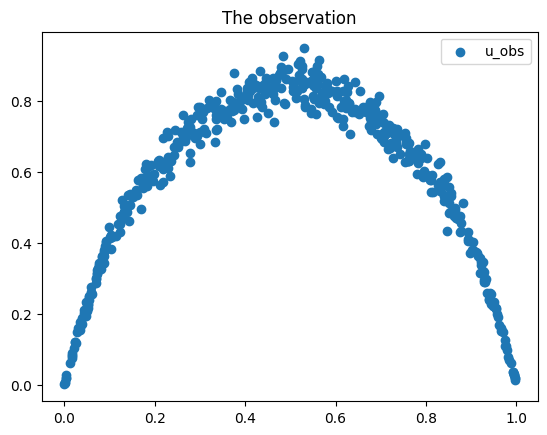

In [88]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
#
with h5py.File('Datasets\ProblemA_dataset.h5', 'r') as file:
    print(file.keys())
    #
    x_obs = np.array(file['x_obs']).reshape(-1,1)
    u_obs = np.array(file['u_obs']).reshape(-1,1)
#
plt.figure()
plt.scatter(x_obs, u_obs, label='u_obs')
plt.title('The observation')
plt.legend()
plt.show()

### Additional Imports and Device Setup

In [89]:
import torch
from torchsummary import summary
from torch.autograd import grad, Variable
from torch.utils.data import Dataset, DataLoader

from tqdm import trange

from scipy.interpolate import griddata

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # Use CUDA if available, else use CPU
dataType = torch.float32    # sets the PyTorch tensor type to 32-bit floating point

np.random.seed(1234)    # fixes NumPy’s random seed, reproducible result
torch.manual_seed(1234) # fixes PyTorch’s random seed, reproducible result

print(f"device: {device}")

device: cuda


### Grid and Collocation points

Size of boundary points: torch.Size([2, 1])
Size of collocation points: torch.Size([10000, 1])
Size of test points: torch.Size([10001, 1])


C:\Users\Manuel Bryan Arsenio\AppData\Local\Temp\ipykernel_28624\3024015686.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_obs = torch.tensor(x_obs, dtype=dataType)
C:\Users\Manuel Bryan Arsenio\AppData\Local\Temp\ipykernel_28624\3024015686.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  u_obs = torch.tensor(u_obs, dtype=dataType)


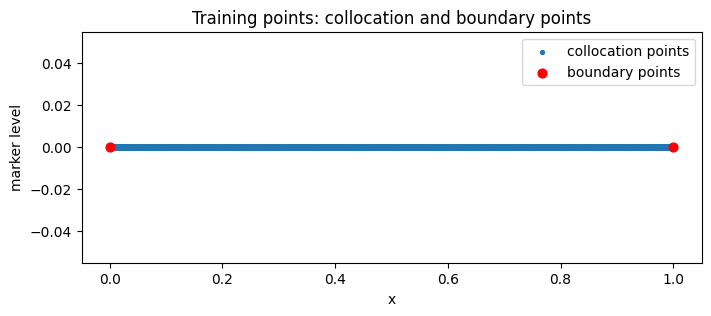

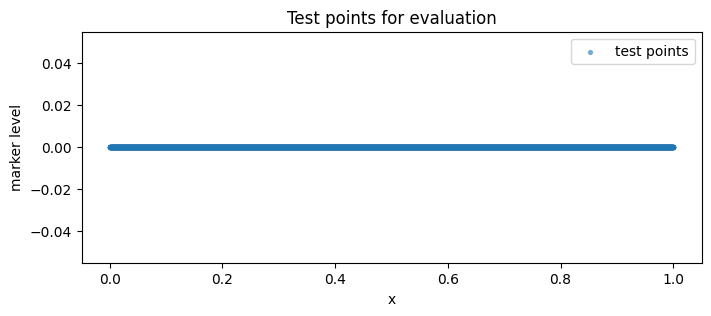

In [100]:
lb, ub = [0.], [1.]
nc = 10000               # number of collocation points

# --- The boundary points (x=0) and (x=1) ---
x_lb = np.array(lb)
x_rb = np.array(ub)

x_bd = np.vstack([x_lb, x_rb])
x_bd = torch.tensor(x_bd, dtype=dataType)
u_bd = torch.tensor([[0.], [0.]], dtype=dataType)
print('Size of boundary points:', x_bd.shape)

# --- The collocation points (x) ---
x_in = np.random.uniform(lb, ub, nc).reshape(-1,1)
x_in = torch.tensor(x_in, dtype=dataType)
print('Size of collocation points:', x_in.shape)

# --- Test points from dataset, used only for evaluation ---
# Extract test data from dataset
with h5py.File('Datasets\ProblemA_dataset.h5', 'r') as file:
    x_test = np.array(file['x_test']).reshape(-1, 1)
    u_test = np.array(file['u_test']).reshape(-1, 1)
    k_test = np.array(file['k_test']).reshape(-1, 1)

x_test = torch.tensor(x_test, dtype=dataType)
u_test = torch.tensor(u_test, dtype=dataType)
k_test = torch.tensor(k_test, dtype=dataType)
print('Size of test points:', x_test.shape)

# --- Convert Observation Points to torch.tensor ---
x_obs = torch.tensor(x_obs, dtype=dataType)
u_obs = torch.tensor(u_obs, dtype=dataType)

# --- Plot 1: Training points ---
plt.figure(figsize=(8, 3))
plt.scatter(x_in.detach().cpu().numpy(), np.zeros_like(x_in.detach().cpu().numpy()), s=8, label='collocation points')
plt.scatter(x_bd.detach().cpu().numpy(), u_bd.detach().cpu().numpy(), color='r', s=40, label='boundary points')

plt.xlabel('x')
plt.ylabel('marker level')
plt.title('Training points: collocation and boundary points')
plt.legend()
plt.show()

# --- Plot 2: Test points ---
plt.figure(figsize=(8, 3))
plt.scatter(x_test.detach().cpu().numpy(), np.zeros_like(x_test.detach().cpu().numpy()), s=8, alpha=0.5, label='test points')

plt.xlabel('x')
plt.ylabel('marker level')
plt.title('Test points for evaluation')
plt.legend()
plt.show()

### Multi-Layer Perceptron

In [101]:
class MLP(torch.nn.Module):

    def __init__(self, layers_list:list, dtype=None):
        super(MLP, self).__init__()

    # layer_list: [x, i, j, k, ..., y]
    # x = number of input features
    # i, j, k = number of neurons in the hidden layers
    # y = number of output features

        # Activation function
        self.activation = torch.nn.Tanh()

        # Building Layers (Network Sequential)
        net = []    # empty list to hold the layers
        self.hidden_in = layers_list[0] # number of input (used in the loop as a variable for the previous layer's number of neurons)

        for hidden_i in layers_list[1:]:
            net.append(torch.nn.Linear(self.hidden_in, hidden_i, dtype=dtype))
            self.hidden_in = hidden_i

        self.net = torch.nn.Sequential(*net)    # takes the list of layers you built and turns it into a PyTorch neural-network container.

    # Forward Pass
    def forward(self, x):
        
        # Input and hidden layers
        for net in self.net[:-1]:
            x = net(x)
            x = self.activation(x)

        # Output layer
        x = self.net[-1](x)

        return x

### Loss Function

In [106]:
class Mollifier(object):
    '''For capturing the dirichlet boundary condition'''
    # Hard constraint for u(0)=u(1)=0
    def apply(self, u, x):
        return torch.sin(torch.pi * x) * u
    
class LossClass(object):

    def __init__(self, u_model, k_model):
        self.device = device
        self.u_model = u_model 
        self.k_model = k_model
        self.getLoss = torch.nn.MSELoss()
        self.mollifier = Mollifier()
    
    # The PDE loss
    def loss_pde(self, x_in):
        '''loss term related to the PDE'''

        # prepares the input points for autograd
        x = Variable(x_in, requires_grad=True).to(self.device)

        # --- LHS -d/dx(k du/dx) ---
        u = self.u_model(x) # compute displacement prediction u(x)
        u = self.mollifier.apply(u, x)  # apply hard boundary constraint
        du_dx = grad(inputs=x, outputs=u, grad_outputs=torch.ones_like(u), create_graph=True)[0]    # compute du/dx
        k = self.k_model(x) # compute Young's modulus prediction k(x)
        k = torch.nn.functional.softplus(k) + 1e-6    # constrain k > 0

        flux = k * du_dx # compute flux: k(x) * du/dx
        dflux_dx = grad(inputs=x, outputs=flux, grad_outputs=torch.ones_like(flux), create_graph=True)[0] # compute d/dx ( k du/dx )

        # --- RHS f = 9.81: body force per unit length ---
        f = 9.81 * torch.ones_like(u)

        # --- residual: LHS - RHS
        residual = -dflux_dx - f

        # Mean squared PDE residual
        loss = self.getLoss(residual, torch.zeros_like(residual))

        return loss

    # Data loss
    def loss_data(self, x_obs, u_obs):
        '''loss term corresponds to the observation'''
        x = x_obs.to(self.device)   # move observation points to the correct device

        u = self.u_model(x) # compute displacement prediction u(x)
        u = self.mollifier.apply(u, x)  # apply hard boundary constraint
        
        loss = self.getLoss(u, u_obs.to(self.device))   # computes the mean squared error between u and u_obs
        
        return loss
    
    # L2 Relative Error - u
    def get_error_u(self, x_test, u_test):
        '''Compute the L2 relative error for u on the test dataset'''

        x_test = x_test.to(self.device)
        u_test = u_test.to(self.device)

        # Raw model prediction
        u_raw = self.u_model(x_test)

        # Apply the same hard boundary constraint as in training
        u_pred = self.mollifier.apply(u_raw, x_test)

        return torch.sqrt(torch.sum((u_pred - u_test)**2) / torch.sum(u_test**2))
    

    # L2 Relative Error - k
    def get_error_k(self, x_test, k_test):
        '''Compute the L2 relative error for k on the test dataset'''

        x_test = x_test.to(self.device)
        k_test = k_test.to(self.device)

        # Raw model prediction
        k_raw = self.k_model(x_test)

        # Apply the same positivity transform as in training
        k_pred = torch.nn.functional.softplus(k_raw) + 1e-6

        return torch.sqrt(torch.sum((k_pred - k_test)**2) / torch.sum(k_test**2))

### Training

In [107]:
# Create a Data Loader for Batch Training

class MyDataset(Dataset):

    def __init__(self, x):
        self.x = x.reshape(-1, 1)

    def __getitem__(self, index):
        return self.x[index]

    def __len__(self):
        return self.x.shape[0]


dataLoader = DataLoader(MyDataset(x_in), batch_size=1000, shuffle=True)

In [108]:
# Training setup

epochs = 10000
lr = 1e-3
model_u = MLP([1, 40, 40, 40, 40, 1], dtype=torch.float32).to(device)
model_k = MLP([1, 40, 40, 40, 40, 1], dtype=torch.float32).to(device)
optimizer = torch.optim.Adam(params=list(model_u.parameters())+list(model_k.parameters()), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=np.int32(epochs/4), gamma=0.5)
w_pde = 2       # pde loss weight
w_data = 200    # data loss weight

In [ ]:
# Training Process

error_u_list, error_k_list = [], []

lossClass = LossClass(model_u, model_k)

for epoch in trange(epochs):

    for x_batch in dataLoader:

        # Calculate losses
        loss_pde = lossClass.loss_pde(x_batch)
        loss_data = lossClass.loss_data(x_obs, u_obs)

        loss_train = w_pde * loss_pde + w_data * loss_data

        # Back propagation
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

    # Evaluate error after each epoch
    with torch.no_grad():
        error_u = lossClass.get_error_u(x_test, u_test)
        error_k = lossClass.get_error_k(x_test, k_test)

        error_u_list.append(error_u.item())
        error_k_list.append(error_k.item())

    scheduler.step()

    if (epoch + 1) % (epochs//4) == 0:
        print(
            f'Epoch: {epoch+1}, '
            f'loss: {loss_train.item():.6e}, '
            f'loss_pde: {loss_pde.item():.6e}, '
            f'loss_data: {loss_data.item():.6e}, '
            f'error_u: {error_u_list[-1]:.6e}, '
            f'error_k: {error_k_list[-1]:.6e}, '
            f'lr: {scheduler.optimizer.param_groups[0]["lr"]:.2e}'
        )

 25%|██▌       | 2501/10000 [09:01<24:13,  5.16it/s]

Epoch: 2500, loss: 1.875204e-01, loss_pde: 1.294606e-03, loss_data: 9.246559e-04, error_u: 1.130767e-02, error_k: 2.497196e-01, lr: 5.00e-04


 50%|█████     | 5001/10000 [17:31<13:34,  6.14it/s]

Epoch: 5000, loss: 1.817682e-01, loss_pde: 8.024544e-04, loss_data: 9.008164e-04, error_u: 8.632991e-03, error_k: 2.107418e-01, lr: 2.50e-04


 75%|███████▌  | 7501/10000 [24:24<06:19,  6.59it/s]

Epoch: 7500, loss: 1.777280e-01, loss_pde: 2.868933e-05, loss_data: 8.883532e-04, error_u: 7.108590e-03, error_k: 1.795483e-01, lr: 1.25e-04


100%|██████████| 10000/10000 [31:08<00:00,  5.35it/s]

Epoch: 10000, loss: 1.756710e-01, loss_pde: 8.246501e-05, loss_data: 8.775301e-04, error_u: 5.677810e-03, error_k: 1.473113e-01, lr: 6.25e-05


### Visualization

In [110]:
# -----------------------------
# Prediction with trained model
# -----------------------------

model_u.eval()
model_k.eval()

with torch.no_grad():

    x_query = x_test.to(device)

    # Predict displacement u(x)
    u_raw = model_u(x_query)
    u_query = lossClass.mollifier.apply(u_raw, x_query)

    # Predict Young's modulus k(x), with positivity constraint
    k_raw = model_k(x_query)
    k_query = torch.nn.functional.softplus(k_raw) + 1e-6

# Move everything to CPU / NumPy for plotting
x_plot = x_test.detach().cpu().numpy()
u_pred = u_query.detach().cpu().numpy()
k_pred = k_query.detach().cpu().numpy()

u_ref = u_test.detach().cpu().numpy()
k_ref = k_test.detach().cpu().numpy()

# Sort by x for clean line plots
sort_idx = np.argsort(x_plot[:, 0])

x_plot = x_plot[sort_idx]
u_pred = u_pred[sort_idx]
k_pred = k_pred[sort_idx]
u_ref = u_ref[sort_idx]
k_ref = k_ref[sort_idx]

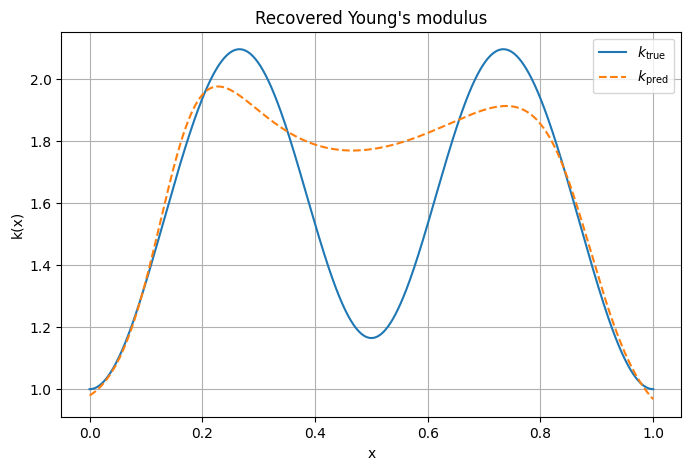

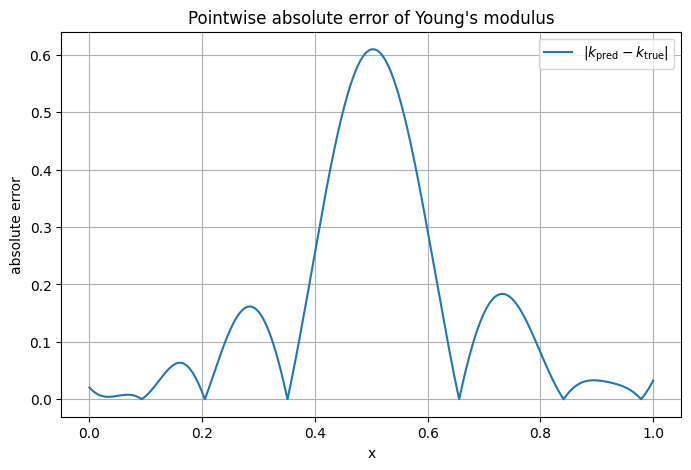

In [111]:
# -----------------------------
# Plot Young's modulus k(x)
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(x_plot, k_ref, label=r'$k_{\mathrm{true}}$')
plt.plot(x_plot, k_pred, '--', label=r'$k_{\mathrm{pred}}$')
plt.xlabel('x')
plt.ylabel('k(x)')
plt.title("Recovered Young's modulus")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# Pointwise absolute error for k
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(x_plot, np.abs(k_pred - k_ref), label=r'$|k_{\mathrm{pred}} - k_{\mathrm{true}}|$')
plt.xlabel('x')
plt.ylabel('absolute error')
plt.title("Pointwise absolute error of Young's modulus")
plt.legend()
plt.grid(True)
plt.show()

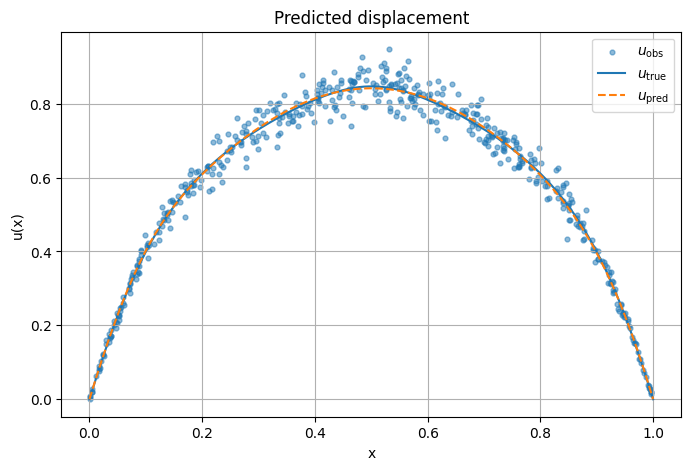

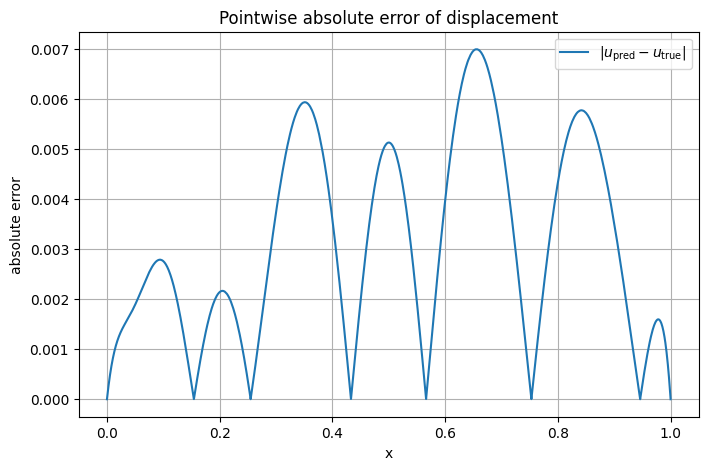

In [112]:
# -----------------------------
# Plot displacement u(x)
# -----------------------------

plt.figure(figsize=(8, 5))
plt.scatter(
    x_obs.detach().cpu().numpy(),
    u_obs.detach().cpu().numpy(),
    s=12,
    alpha=0.5,
    label=r'$u_{\mathrm{obs}}$'
)
plt.plot(x_plot, u_ref, label=r'$u_{\mathrm{true}}$')
plt.plot(x_plot, u_pred, '--', label=r'$u_{\mathrm{pred}}$')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Predicted displacement')
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# Pointwise absolute error for u
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(x_plot, np.abs(u_pred - u_ref), label=r'$|u_{\mathrm{pred}} - u_{\mathrm{true}}|$')
plt.xlabel('x')
plt.ylabel('absolute error')
plt.title('Pointwise absolute error of displacement')
plt.legend()
plt.grid(True)
plt.show()

Final relative L2 error for u: 5.677810e-03
Final relative L2 error for k: 1.473113e-01


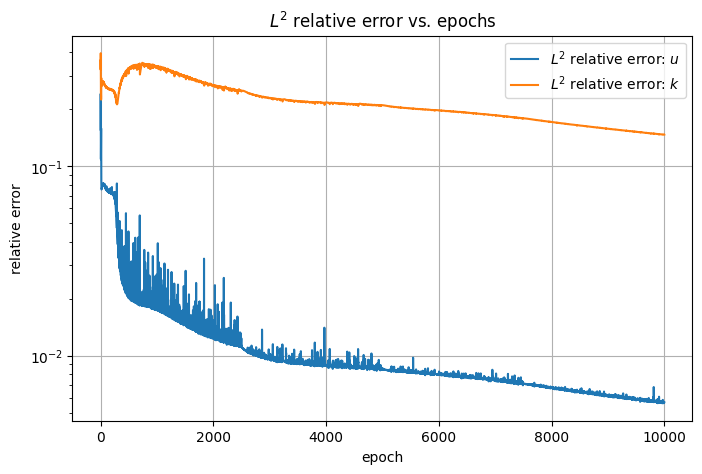

In [113]:
# -----------------------------
# Final relative L2 errors
# -----------------------------

error_u = np.sqrt(np.sum((u_pred - u_ref)**2) / np.sum(u_ref**2))
error_k = np.sqrt(np.sum((k_pred - k_ref)**2) / np.sum(k_ref**2))

print(f"Final relative L2 error for u: {error_u:.6e}")
print(f"Final relative L2 error for k: {error_k:.6e}")

# -----------------------------
# Error history
# -----------------------------

plt.figure(figsize=(8, 5))
plt.semilogy(error_u_list, label=r'$L^2$ relative error: $u$')
plt.semilogy(error_k_list, label=r'$L^2$ relative error: $k$')
plt.xlabel('epoch')
plt.ylabel('relative error')
plt.title(r'$L^2$ relative error vs. epochs')
plt.legend()
plt.grid(True)
plt.show()